#  Exploratory Data Analysis (EDA)

**Team 28**

## Goal
Identify the main characteristics of the data, distributions, missing values, outliers, and relationships before modeling.

## Analyzed Tables
1. **repo_languages.csv** – programming languages and code volumes in repositories  
2. **events_daily.csv** – daily GitHub events (Push, Create, Watch, etc.)  
3. **repo_metadata.csv** – repository metadata (id, name, first seen date)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

!pip install gdown -q

# Google Drive folder ID (from the shared link)
FOLDER_ID = "1rsWlKjhOOJYaZ40K_lm3ZBffBBebIrt9"

# Download the entire folder
!gdown --folder {FOLDER_ID}

!ls -lh csv_data/

DATA_DIR = "csv_data"

Retrieving folder contents
Processing file 1DPY7PL3wK14c7xHKLiBjjxBauZP0xMfW events_daily.csv
Processing file 16Tvtn__M-OtHp5zzi8Y0r2l4S-9X2zQn repo_languages.csv
Processing file 1FgxCE7XuFV8_2Y2QYVitjG7xLHm6HFoV repo_metadata.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1DPY7PL3wK14c7xHKLiBjjxBauZP0xMfW
From (redirected): https://drive.google.com/uc?id=1DPY7PL3wK14c7xHKLiBjjxBauZP0xMfW&confirm=t&uuid=fe46ab24-b57e-465e-8d7f-a1a361242ab0
To: /content/csv_data/events_daily.csv
100% 2.85G/2.85G [00:31<00:00, 91.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=16Tvtn__M-OtHp5zzi8Y0r2l4S-9X2zQn
From (redirected): https://drive.google.com/uc?id=16Tvtn__M-OtHp5zzi8Y0r2l4S-9X2zQn&confirm=t&uuid=d5bf88f7-6fca-440a-b624-d96cbe3ba02b
To: /content/csv_data/repo_languages.csv
100% 111M/111M [00:01<00:00, 90.6MB/s]
Downloading...
From (original): https:

###Loading and initial inspection of data

In [2]:
# 1.1 repo_languages
df_lang = pd.read_csv(f"{DATA_DIR}/repo_languages.csv")
print("="*70)
print("repo_languages.csv")
print("="*70)
print(f"Shape: {df_lang.shape[0]:,} rows, {df_lang.shape[1]} columns")
print("\nData info:")
df_lang.info()
print("\nFirst 5 rows:")
print(df_lang.head())
print("\n" + "-"*70)

# 1.2 events_daily (metadata without full loading)
file_path = f"{DATA_DIR}/events_daily.csv"
size_mb = os.path.getsize(file_path) / (1024*1024)
line_count = int(subprocess.check_output(f"wc -l {file_path}", shell=True).split()[0])
cols = pd.read_csv(file_path, nrows=0).columns.tolist()
print("\n" + "="*70)
print("events_daily.csv")
print("="*70)
print(f"File size: {size_mb:.2f} MB")
print(f"Lines (including header): {line_count:,}")
print(f"Columns: {len(cols)}")
print(f"Column names: {cols}")
sample_types = pd.read_csv(file_path, nrows=1000).dtypes
print("\nData types (based on first 1000 rows):")
print(sample_types)
print("\nFirst 5 rows (sample):")
print(pd.read_csv(file_path, nrows=5))
print("\n" + "-"*70)

# 1.3 repo_metadata
df_meta = pd.read_csv(f"{DATA_DIR}/repo_metadata.csv")
print("\n" + "="*70)
print("repo_metadata.csv")
print("="*70)
print(f"Shape: {df_meta.shape[0]:,} rows, {df_meta.shape[1]} columns")
print("\nData info:")
df_meta.info()
print("\nFirst 5 rows:")
print(df_meta.head())

repo_languages.csv
Shape: 2,957,293 rows, 3 columns

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2957293 entries, 0 to 2957292
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   repo_name       object
 1   language        object
 2   language_bytes  int64 
dtypes: int64(1), object(2)
memory usage: 67.7+ MB

First 5 rows:
                        repo_name       language  language_bytes
0                    pallid/Tasks  1C Enterprise        31948222
1           Diversus23/uni_script  1C Enterprise          412946
2  silverbulleters/vanessa-runner  1C Enterprise          799195
3                   BUDIVAL/Tasks  1C Enterprise        31540275
4   alkoleft/ones_universal_tools  1C Enterprise          320324

----------------------------------------------------------------------

events_daily.csv
File size: 2718.78 MB
Lines (including header): 44,706,264
Columns: 6
Column names: ['event_type', 'repo_id', 'repo_name', 'event_date', '

###Quality control

At this stage, we check the quality of the data (for missing values, duplicates, data types, and logical errors).

In [3]:
# 2.1 repo_languages
print("="*70)
print("repo_languages.csv – quality check")
print("="*70)
print("Missing values:")
print(df_lang.isnull().sum())
print("\nDuplicate rows:", df_lang.duplicated().sum())
print("\nData types:")
print(df_lang.dtypes)
print("\n" + "-"*70)

# 2.2 events_daily (via chunks – missing values and logical errors)
print("\n" + "="*70)
print("events_daily.csv – quality check (by chunks)")
print("="*70)
chunk_size = 500000
total_rows = 0
missing_counts = {}
neg_counts = {'event_count': 0, 'unique_actors': 0, 'repo_id': 0}
chunk_iter = pd.read_csv(file_path, chunksize=chunk_size)
for i, chunk in enumerate(chunk_iter):
    total_rows += len(chunk)
    for col in ['event_type', 'repo_id', 'repo_name', 'event_date', 'event_count', 'unique_actors']:
        missing_counts[col] = missing_counts.get(col, 0) + chunk[col].isnull().sum()
    neg_counts['event_count'] += (chunk['event_count'] < 0).sum()
    neg_counts['unique_actors'] += (chunk['unique_actors'] < 0).sum()
    neg_counts['repo_id'] += (chunk['repo_id'] <= 0).sum()
    if (i+1) % 5 == 0:
        print(f"Processed {i+1} chunks, rows: {total_rows:,}")
print(f"\nTotal rows: {total_rows:,}")
print("\nMissing values:")
for col, miss in missing_counts.items():
    if miss > 0:
        print(f"  {col}: {miss} ({miss/total_rows*100:.4f}%)")
    else:
        print(f"  {col}: no missing")
print("\nLogical errors (negative/invalid values):")
for col, cnt in neg_counts.items():
    if cnt > 0:
        print(f"  {col}: {cnt}")
    else:
        print(f"  {col}: none")
print("\n" + "-"*70)

# 2.3 repo_metadata
print("\n" + "="*70)
print("repo_metadata.csv – quality check")
print("="*70)
print("Missing values:")
print(df_meta.isnull().sum())
print("\nDuplicate rows:", df_meta.duplicated().sum())
print("\nData types:")
print(df_meta.dtypes)

repo_languages.csv – quality check
Missing values:
repo_name         0
language          0
language_bytes    0
dtype: int64

Duplicate rows: 0

Data types:
repo_name         object
language          object
language_bytes     int64
dtype: object

----------------------------------------------------------------------

events_daily.csv – quality check (by chunks)
Processed 5 chunks, rows: 2,500,000
Processed 10 chunks, rows: 5,000,000
Processed 15 chunks, rows: 7,500,000
Processed 20 chunks, rows: 10,000,000
Processed 25 chunks, rows: 12,500,000
Processed 30 chunks, rows: 15,000,000
Processed 35 chunks, rows: 17,500,000
Processed 40 chunks, rows: 20,000,000
Processed 45 chunks, rows: 22,500,000
Processed 50 chunks, rows: 25,000,000
Processed 55 chunks, rows: 27,500,000
Processed 60 chunks, rows: 30,000,000
Processed 65 chunks, rows: 32,500,000
Processed 70 chunks, rows: 35,000,000
Processed 75 chunks, rows: 37,500,000
Processed 80 chunks, rows: 40,000,000
Processed 85 chunks, rows: 42,500

### Statistics of numerical features

In [5]:
# 3.1 repo_languages
print("="*70)
print("repo_languages.csv – statistics of language_bytes")
print("="*70)
print(df_lang['language_bytes'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print(f"\nSkewness: {df_lang['language_bytes'].skew():.2f}")
print("\n" + "-"*70)

# 3.2 events_daily (on a sample of 10,000 rows)
print("\n" + "="*70)
print("events_daily.csv – statistics of event_count and unique_actors (on a sample of 10,000 rows)")
print("="*70)
sample_events = pd.read_csv(file_path, nrows=10000)
print(sample_events[['event_count', 'unique_actors']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print(f"\nPearson correlation: {sample_events['event_count'].corr(sample_events['unique_actors']):.3f}")
print("\n" + "-"*70)

# 3.3 repo_metadata
print("\n" + "="*70)
print("repo_metadata.csv – statistics of repo_id")
print("="*70)
print(df_meta['repo_id'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print(f"\nUniqueness of repo_id: {df_meta['repo_id'].is_unique}")

repo_languages.csv – statistics of language_bytes
count      2957293.00
mean       3071185.62
std       40442945.94
min              0.00
1%             259.00
5%            1369.00
25%           8389.00
50%          31999.00
75%         164507.00
95%        3747276.80
99%       27381310.76
max     5395746994.00
Name: language_bytes, dtype: float64

Skewness: 43.71

----------------------------------------------------------------------

events_daily.csv – statistics of event_count and unique_actors (on a sample of 10,000 rows)
       event_count  unique_actors
count     10000.00       10000.00
mean          1.70           1.03
std           4.29           0.26
min           1.00           1.00
1%            1.00           1.00
5%            1.00           1.00
25%           1.00           1.00
50%           1.00           1.00
75%           2.00           1.00
95%           3.00           1.00
99%           6.00           2.00
max         404.00          12.00

Pearson correlation: 0.0

-We analyzed the repo_languages.csv table based on the language_bytes column and found that the distribution is heavily skewed to the right (skewness = 43.71), meaning that almost all repositories are tiny (with a median size of approximately 32 KB), but there are a few very large repositories that exceed 5 billion bytes. The 95th and 99th percentiles (3.7 MB and 27.4 MB) confirm the extreme variation even among top-tier projects. language_bytes shows how much code there is in the project, which is a great indicator of its scale and complexity. Based on this, we can conclude that for anomaly models, it is necessary to use logarithms to remove outliers and make the data normal.

-When we analyzed the events_daily.csv table using the event_count and unique_actors features, we found that these features are independent of each other and can be used to identify anomalies.

-When working with the repo_metadata.csv table, we found that although the repo_id values vary widely (from 130 to more than 822 million), the column is not unique (unique: False), which means that there are duplicates that need to be removed before any reliable joins with other tables.

### Analysis of categorical features

This stage helps us understand which languages and events are prevalent, and how repositories are distributed by year.

In [6]:
# 4.1 repo_languages – languages
print("="*70)
print("repo_languages.csv – top-10 languages by number of repositories")
print("="*70)
print(df_lang['language'].value_counts().head(10))
print("\nTop-10 languages by total code volume:")
print(df_lang.groupby('language')['language_bytes'].sum().sort_values(ascending=False).head(10))
print("\n" + "-"*70)

# 4.2 events_daily – event types (on sample)
print("\n" + "="*70)
print("events_daily.csv – top-10 event types (on a sample of 10,000 rows)")
print("="*70)
print(sample_events['event_type'].value_counts().head(10))
push_pct = (sample_events['event_type'] == 'PushEvent').mean() * 100
print(f"\nShare of PushEvent: {push_pct:.1f}%")
print("\n" + "-"*70)

# 4.3 repo_metadata – first seen date (grouped by year)
print("\n" + "="*70)
print("repo_metadata.csv – distribution by first seen year")
print("="*70)
# Convert date if not already done
df_meta['repo_first_seen'] = pd.to_datetime(df_meta['repo_first_seen'], errors='coerce')
year_counts = df_meta['repo_first_seen'].dt.year.value_counts().sort_index()
print(year_counts.head(10))
print(f"\nEarliest date: {df_meta['repo_first_seen'].min()}")
print(f"Latest date: {df_meta['repo_first_seen'].max()}")

repo_languages.csv – top-10 languages by number of repositories
language
JavaScript    611112
Python        341105
Java          297586
PHP           237274
Ruby          194276
C++           138824
HTML          137681
C             133589
CSS           127147
C#            100982
Name: count, dtype: int64

Top-10 languages by total code volume:
language
C                   5842140266149
JavaScript          1100866331897
PHP                  476185351977
C++                  371540951924
Java                 275381410067
HTML                 275023035003
Python               148325719683
C#                   119219561832
Go                    66255194314
Jupyter Notebook      63224976802
Name: language_bytes, dtype: int64

----------------------------------------------------------------------

events_daily.csv – top-10 event types (on a sample of 10,000 rows)
event_type
CreateEvent    10000
Name: count, dtype: int64

Share of PushEvent: 0.0%

------------------------------------------

### Visualization of feature distributions

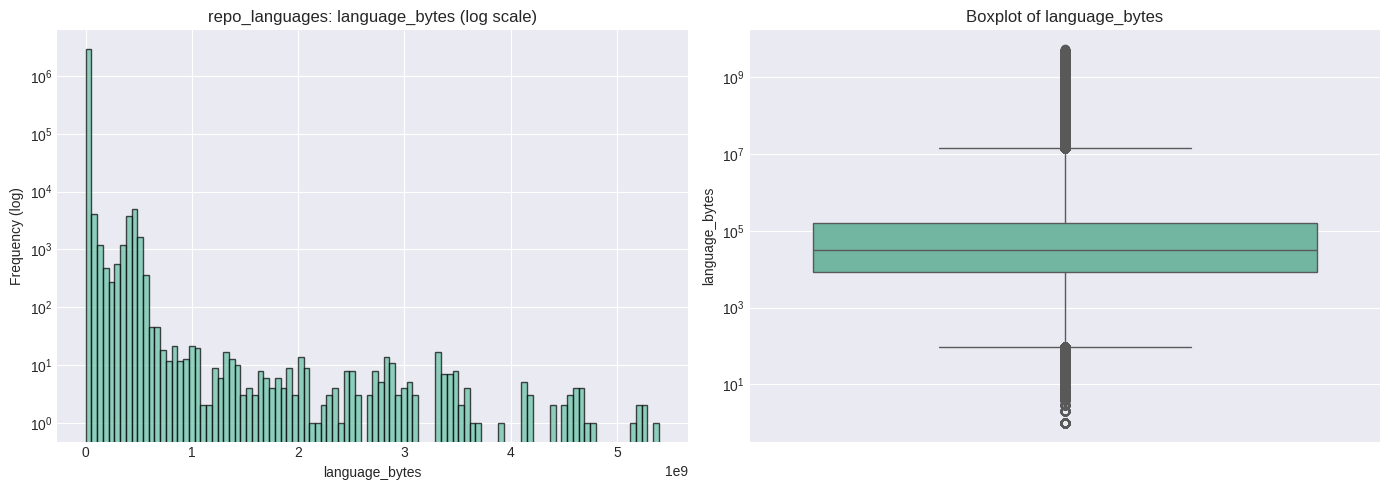

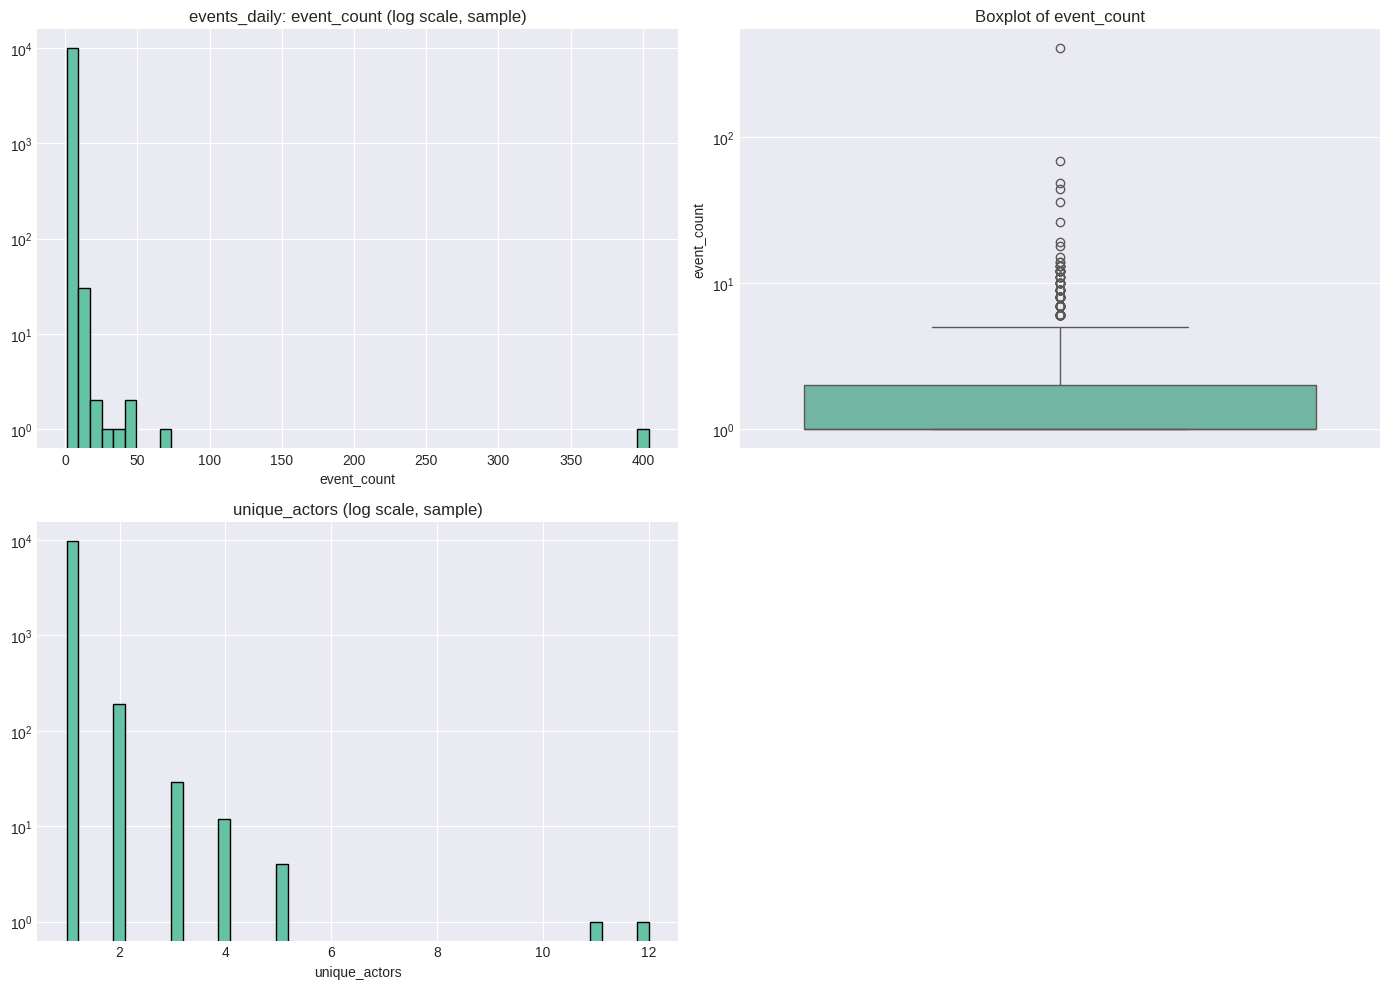

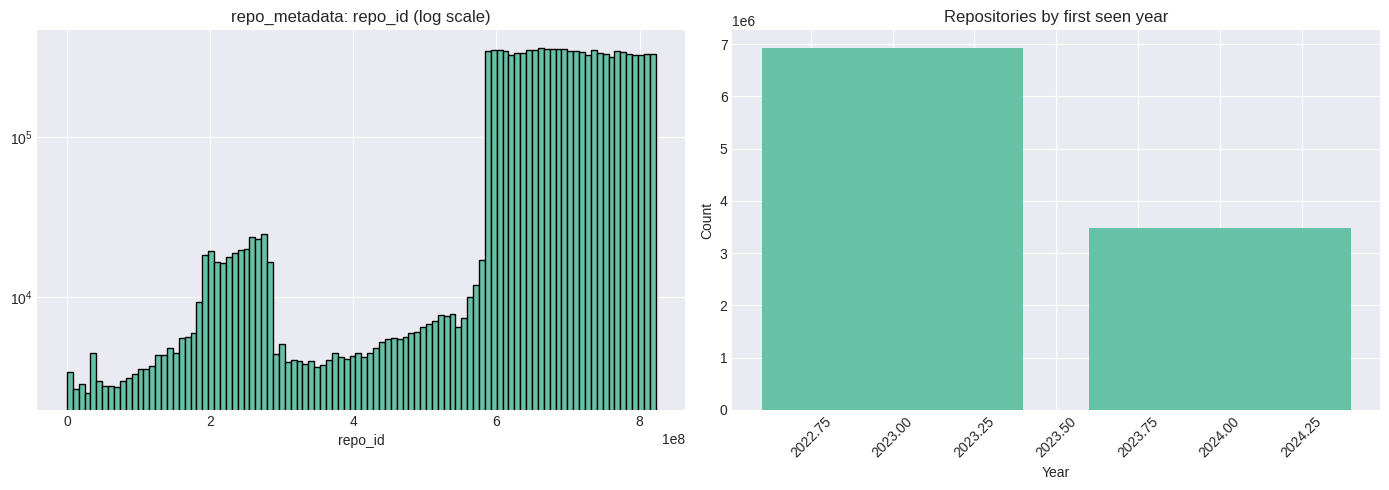

In [8]:
# 5.1 repo_languages – language_bytes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_lang['language_bytes'], bins=100, log=True, edgecolor='black', alpha=0.7)
axes[0].set_title('repo_languages: language_bytes (log scale)')
axes[0].set_xlabel('language_bytes')
axes[0].set_ylabel('Frequency (log)')
sns.boxplot(y=df_lang['language_bytes'], ax=axes[1], log_scale=True)
axes[1].set_title('Boxplot of language_bytes')
plt.tight_layout()
plt.show()

# 5.2 events_daily – event_count (hist + boxplot) and unique_actors (only hist)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# event_count histogram
axes[0,0].hist(sample_events['event_count'], bins=50, log=True, edgecolor='black')
axes[0,0].set_title('events_daily: event_count (log scale, sample)')
axes[0,0].set_xlabel('event_count')
# event_count boxplot
sns.boxplot(y=sample_events['event_count'], ax=axes[0,1], log_scale=True)
axes[0,1].set_title('Boxplot of event_count')
# unique_actors histogram (only)
axes[1,0].hist(sample_events['unique_actors'], bins=50, log=True, edgecolor='black')
axes[1,0].set_title('unique_actors (log scale, sample)')
axes[1,0].set_xlabel('unique_actors')
# remove the last subplot (boxplot for unique_actors)
fig.delaxes(axes[1,1])
plt.tight_layout()
plt.show()

# 5.3 repo_metadata – repo_id and first seen year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_meta['repo_id'], bins=100, log=True, edgecolor='black')
axes[0].set_title('repo_metadata: repo_id (log scale)')
axes[0].set_xlabel('repo_id')
year_counts = df_meta['repo_first_seen'].dt.year.value_counts().sort_index()
axes[1].bar(year_counts.index, year_counts.values, width=0.8)
axes[1].set_title('Repositories by first seen year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Time series analysis

In this skin, we aggregate daily GitHub event data to build time series of total activity. This helps us identify anomalous days with sudden spikes in activity

Time series created. Date range:
  from 2023-01-01 00:00:00 to 2024-06-30 00:00:00
Total days: 547


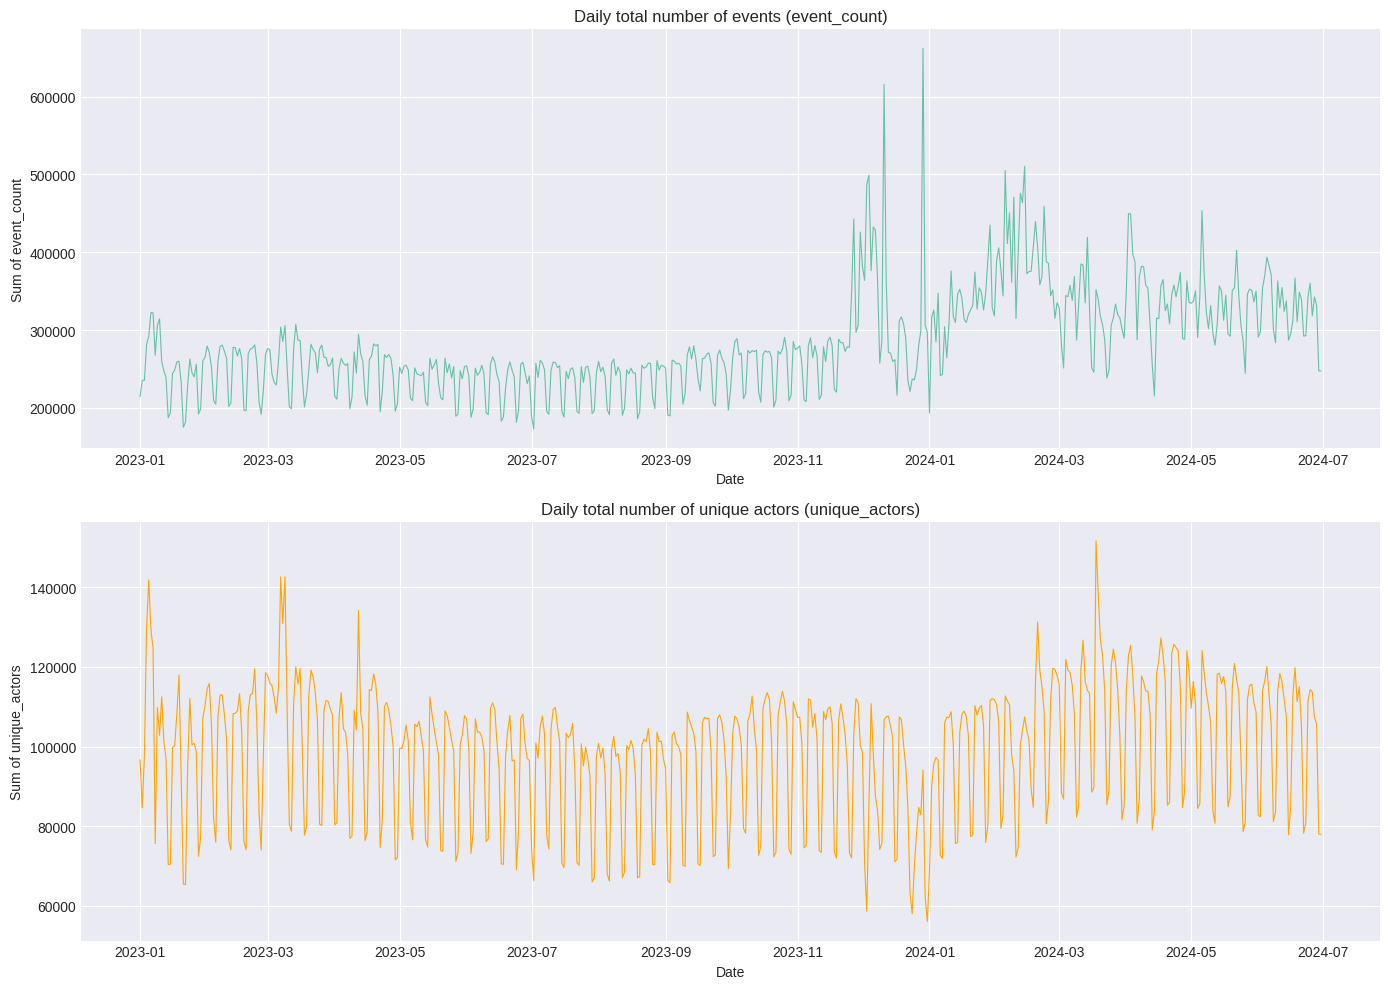


Top 5 days by event_count:
    event_date  total_event_count
362 2023-12-29          661922.00
344 2023-12-11          615537.00
409 2024-02-14          510409.00
400 2024-02-05          505081.00
337 2023-12-04          499054.00

Top 5 days by unique_actors:
    event_date  total_unique_actors
442 2024-03-18            151621.00
67  2023-03-09            142609.00
65  2023-03-07            142583.00
4   2023-01-05            141805.00
443 2024-03-19            138547.00


In [9]:

# Aggregate events_daily by day using chunks (without loading the entire file)
chunk_size = 500000
daily_stats = {}

chunk_iter = pd.read_csv(f"{DATA_DIR}/events_daily.csv", chunksize=chunk_size)
for chunk in chunk_iter:
    # Convert date
    chunk['event_date'] = pd.to_datetime(chunk['event_date'])
    # Group by date within the chunk and sum
    daily = chunk.groupby('event_date').agg(
        total_event_count=('event_count', 'sum'),
        total_unique_actors=('unique_actors', 'sum')
    ).reset_index()
    # Merge with the main dictionary
    for _, row in daily.iterrows():
        d = row['event_date']
        if d not in daily_stats:
            daily_stats[d] = {'total_event_count': 0, 'total_unique_actors': 0}
        daily_stats[d]['total_event_count'] += row['total_event_count']
        daily_stats[d]['total_unique_actors'] += row['total_unique_actors']

# Convert to DataFrame
df_daily = pd.DataFrame.from_dict(daily_stats, orient='index').reset_index()
df_daily.columns = ['event_date', 'total_event_count', 'total_unique_actors']
df_daily = df_daily.sort_values('event_date')

print("Time series created. Date range:")
print(f"  from {df_daily['event_date'].min()} to {df_daily['event_date'].max()}")
print(f"Total days: {len(df_daily)}")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes[0].plot(df_daily['event_date'], df_daily['total_event_count'], linewidth=0.8)
axes[0].set_title('Daily total number of events (event_count)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sum of event_count')
axes[0].grid(True)

axes[1].plot(df_daily['event_date'], df_daily['total_unique_actors'], linewidth=0.8, color='orange')
axes[1].set_title('Daily total number of unique actors (unique_actors)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sum of unique_actors')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Brief analysis: finding anomalous days (peaks)
print("\nTop 5 days by event_count:")
print(df_daily.nlargest(5, 'total_event_count')[['event_date', 'total_event_count']])
print("\nTop 5 days by unique_actors:")
print(df_daily.nlargest(5, 'total_unique_actors')[['event_date', 'total_unique_actors']])

### Investigation of the interrelationships between the signs

In this code, we analyze the relationships between numerical event features.

--- Correlation in events_daily (on a sample of 10,000 rows) ---
               repo_id  event_count  unique_actors
repo_id           1.00         0.06          -0.02
event_count       0.06         1.00           0.09
unique_actors    -0.02         0.09           1.00


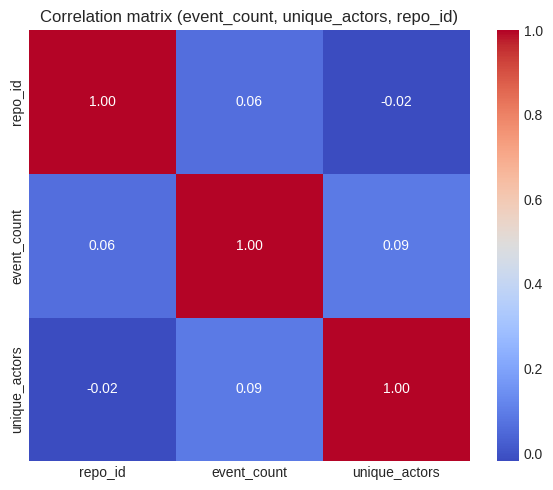


--- Average event_count by event type (on sample) ---
event_type
CreateEvent   1.70
Name: event_count, dtype: float64

--- Monthly aggregated metrics ---
         total_event_count  total_unique_actors
month                                          
2023-01         7669573.00           3067942.00
2023-02         6989430.00           2814035.00
2023-03         8059155.00           3372043.00
2023-04         7379244.00           2964207.00
2023-05         7374157.00           2984558.00


In [13]:

# 7.1 Correlation matrix for events_daily (on sample)
print("--- Correlation in events_daily (on a sample of 10,000 rows) ---")
sample_events = pd.read_csv(f"{DATA_DIR}/events_daily.csv", nrows=10000)
numeric_cols = ['repo_id', 'event_count', 'unique_actors']
corr_matrix = sample_events[numeric_cols].corr()
print(corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix (event_count, unique_actors, repo_id)')
plt.tight_layout()
plt.show()


# 7.2 Groupby aggregations: average event_count by event type
print("\n--- Average event_count by event type (on sample) ---")
grouped = sample_events.groupby('event_type')['event_count'].mean().sort_values(ascending=False).head(10)
print(grouped)

# 7.3 If date exists, aggregate by month (using df_daily)
if 'df_daily' in locals():
    df_daily['month'] = df_daily['event_date'].dt.to_period('M')
    monthly = df_daily.groupby('month')[['total_event_count', 'total_unique_actors']].sum()
    print("\n--- Monthly aggregated metrics ---")
    print(monthly.head())

### Subgroup analysis

At this stage, we identify and compare key subgroups of repositories for further work on the business task.

In [15]:

# 8.1 Young repositories (< 180 days) – already have young_repos from previous steps
if 'young_repos' not in locals():
    df_meta['repo_first_seen'] = pd.to_datetime(df_meta['repo_first_seen'], errors='coerce')
    max_date = df_meta['repo_first_seen'].max()
    cutoff = max_date - pd.Timedelta(days=180)
    young_repos = df_meta[df_meta['repo_first_seen'] >= cutoff]

print(f"Total repositories: {len(df_meta):,}")
print(f"Young repositories (<180 days): {len(young_repos):,} ({len(young_repos)/len(df_meta)*100:.1f}%)")

# 8.2 Compare language distribution between young and all (if merged with repo_languages)
merged_all = pd.merge(df_meta, df_lang, on='repo_name', how='inner')
merged_young = pd.merge(young_repos, df_lang, on='repo_name', how='inner')

top_langs_all = merged_all.groupby('language')['repo_id'].nunique().sort_values(ascending=False).head(5)
top_langs_young = merged_young.groupby('language')['repo_id'].nunique().sort_values(ascending=False).head(5)

print("\nTop-5 languages among ALL repositories (by number of repos):")
print(top_langs_all)
print("\nTop-5 languages among YOUNG repositories:")
print(top_langs_young)

# 8.3 Identify repositories with high event_count (e.g., > 95th percentile) – using sample_events
print("\n--- Analysis of repositories with high event activity ---")
agg_by_repo = sample_events.groupby('repo_id').agg(
    total_events=('event_count', 'sum'),
    total_actors=('unique_actors', 'sum')
).reset_index()
threshold_events = agg_by_repo['total_events'].quantile(0.95)
high_activity = agg_by_repo[agg_by_repo['total_events'] > threshold_events]
print(f"95th percentile of total_events: {threshold_events:.0f}")
print(f"Repositories with high activity (>95th percentile): {len(high_activity)}")
print("Examples of such repo_id:", high_activity['repo_id'].head(5).tolist())

Total repositories: 10,389,095
Young repositories (<180 days): 3,444,228 (33.2%)

Top-5 languages among ALL repositories (by number of repos):
language
JavaScript    1588
Python        1197
Java           824
PHP            777
Ruby           617
Name: repo_id, dtype: int64

Top-5 languages among YOUNG repositories:
language
JavaScript    179
Python        147
PHP            93
Java           83
HTML           65
Name: repo_id, dtype: int64

--- Analysis of repositories with high event activity ---
95th percentile of total_events: 3
Repositories with high activity (>95th percentile): 342
Examples of such repo_id: [2296970, 3766330, 22886300, 30985840, 31899330]


### emissions and anomalies


In [16]:
from scipy import stats

# 9.1 For language_bytes (repo_languages)
z_lang = np.abs(stats.zscore(df_lang['language_bytes'].dropna()))
outliers_lang = df_lang['language_bytes'].iloc[np.where(z_lang > 3)[0]]
print(f"language_bytes: outliers |z|>3: {len(outliers_lang)} ({len(outliers_lang)/len(df_lang)*100:.2f}%)")

# 9.2 For event_count and unique_actors (on sample)
z_event = np.abs(stats.zscore(sample_events['event_count'].dropna()))
outliers_event = sample_events['event_count'].iloc[np.where(z_event > 3)[0]]
print(f"event_count: outliers |z|>3: {len(outliers_event)} ({len(outliers_event)/len(sample_events)*100:.2f}%)")

z_actors = np.abs(stats.zscore(sample_events['unique_actors'].dropna()))
outliers_actors = sample_events['unique_actors'].iloc[np.where(z_actors > 3)[0]]
print(f"unique_actors: outliers |z|>3: {len(outliers_actors)} ({len(outliers_actors)/len(sample_events)*100:.2f}%)")

language_bytes: outliers |z|>3: 14641 (0.50%)
event_count: outliers |z|>3: 9 (0.09%)
unique_actors: outliers |z|>3: 236 (2.36%)
